# Fine-Tune an LLM with LoRA and QLoRA

## What You'll Build

In this lab, you'll take **Meta Llama 3 8B** — a raw base model with no instruction-following ability — and fine-tune it into a medical Q&A specialist. By the end, your model will go from incoherent text completion to structured, accurate clinical answers.

**The journey:**
1. Explore what the base model can and can't do (spoiler: it can't follow instructions)
2. Prepare a training dataset in the right format
3. Understand LoRA — how and why it works
4. Run QLoRA fine-tuning and watch loss decrease
5. Understand quantization — FP16 vs 4-bit
6. Evaluate: see the dramatic before/after difference
7. Merge and export your fine-tuned model

---

## Step 1: Explore the Base Model

Before fine-tuning, you need to understand what the model **can't** do. The base Llama 3 8B was trained on raw text — it predicts the next token, nothing more. It has never been taught to follow instructions or answer questions.

Ask it "What is diabetes?" and it'll respond with something like *"What is diabetes? It is a disease that..."* — just continuing the text pattern, not answering your question.

This is what makes fine-tuning so valuable: you take this raw capability and shape it into something useful.

### Load the base model

Let's load Llama 3 8B (the **base** version — no instruction tuning).

In Hugging Face Transformers, you load models and tokenizers with `from_pretrained()`:

```python
tokenizer = AutoTokenizer.from_pretrained("model-path")
model = AutoModelForCausalLM.from_pretrained("model-path", ...)
```

Both are already imported above. The model path is stored in `model_name`. For loading the model, pass these two keyword arguments:
- **`dtype=torch.float16`** — half precision, uses ~16 GB VRAM instead of ~32 GB
- **`device_map="auto"`** — automatically places layers on available GPUs

Fill in the two blanks:

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "/models/meta-llama--Meta-Llama-3-8B"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Load the model in float16 on GPU
model = AutoModelForCausalLM.from_pretrained(model_name,dtype=torch.float16,device_map="auto")

print(f"Model loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M parameters")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded: 8030M parameters
VRAM used: 16.1 GB


### Test the base model

Now let's send medical questions to the base model. Pay attention to how it responds — it should **not** answer the questions properly. Instead, it will just continue the text pattern (like autocomplete).

This is the behavior we'll fix through fine-tuning. Run the cell below (no changes needed).

In [2]:
prompts = [
    "What are the first-line treatments for Type 2 diabetes?",
    "A patient presents with sudden chest pain and shortness of breath. What is the most likely diagnosis?",
    "List the contraindications for metformin.",
]

for prompt in prompts:
    print(f"\n{'='*60}")
    print(f"Q: {prompt}")
    print(f"{'='*60}")

    # Base model has no chat template — just feed raw text
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"A: {response}")

print("\n\nNotice: the base model doesn't answer questions — it just completes text.")
print("After fine-tuning, it will actually follow instructions and give structured answers.")


Q: What are the first-line treatments for Type 2 diabetes?
A:  | Health
Type 2 diabetes is the most common type of diabetes and is associated with insulin resistance, which means the body doesn’t respond to insulin. The disease is also associated with obesity and is often found in people over the age of 40, although it can occur at any age. However, this is not the case with type 1 diabetes, which is usually diagnosed in childhood and is associated with insulin deficiency.
Type 2 diabetes is characterized by high blood sugar levels, which can lead to serious complications. The disease can affect various parts of the body, including the eyes, kidneys, nerves, and heart. If left untreated, diabetes can lead to blindness, kidney failure, heart disease, and stroke. However, with the right treatment

Q: A patient presents with sudden chest pain and shortness of breath. What is the most likely diagnosis?
A:  (Select one)
A 45-year-old male presents to the emergency department with sudden on

See how the base model just rambles? It might repeat the question, continue with loosely related text, or go off on tangents. It has knowledge about medicine (it was trained on internet text) but it has no ability to follow instructions.

By Step 6, your fine-tuned model will answer these same questions with structured, concise responses.

Click **Check Step 1** below when you're ready to continue.

In [3]:
from preporato_labs import Lab
lab = Lab('fine-tune-llm-lora-jupyter')
lab.check(1)

Model: 8030M params on cuda:0
VRAM: 16.1 GB
--- Step 1 Complete! Scroll down to continue... ---
STEP_PASSED


Step 1 Complete! Scroll down to continue...

True

## Step 2: Prepare the Training Dataset

Fine-tuning is only as good as your data. A poorly formatted dataset teaches the model bad habits. A well-structured one makes it dramatically better.

**What we need to do:**
1. Load a dataset (Alpaca — 52K instruction/response pairs)
2. Filter to medical examples only
3. Format each example into the Alpaca instruction template
4. Split into train/validation sets
5. Tokenize for the model

> **NCP-GENL exam note:** Data preparation is 22% of the exam (Domain 3). The exam tests understanding of data formats, tokenization strategies, and quality filtering — exactly what you're doing here.

### Load the Alpaca dataset

The Alpaca dataset is pre-downloaded on this GPU instance at `/models/datasets/alpaca`. Each example has:
- **instruction** — what the user is asking
- **input** — optional additional context
- **output** — the ideal response

Use `load_dataset()` with the path to load it. Fill in the blank:

In [4]:
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("/models/meta-llama--Meta-Llama-3-8B")
tokenizer.pad_token = tokenizer.eos_token

# Load the Alpaca dataset from the pre-downloaded path
dataset = load_dataset("/models/datasets/alpaca")

print(f"Total examples: {len(dataset['train'])}")
print(f"\nSample entry:")
print(f"  instruction: {dataset['train'][0]['instruction'][:100]}")
print(f"  output: {dataset['train'][0]['output'][:100]}")

Generating train split: 0 examples [00:00, ? examples/s]

Total examples: 52002

Sample entry:
  instruction: Give three tips for staying healthy.
  output: 1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regular


### Filter to medical examples

We only want medical/health-related examples for our fine-tuning task. We'll filter by keyword matching — examples that contain at least 2 medical keywords (like "patient" + "treatment"). We cap at 2000 examples — enough for strong improvement, trains in ~10 minutes with QLoRA.

In production you'd use more sophisticated methods (embeddings, LLM classification). Run this cell as-is:

In [5]:
medical_keywords = [
    'patient', 'treatment', 'diagnosis', 'symptom', 'medical',
    'disease', 'clinical', 'therapy', 'prescription', 'surgery'
]

def is_medical(example):
    text = (example['instruction'] + ' ' + example.get('input', '') + ' ' + example['output']).lower()
    return any(kw in text for kw in medical_keywords)

medical_data = dataset['train'].filter(is_medical)

# Cap at 2000 examples — strong improvement, trains in ~10 min with QLoRA
if len(medical_data) > 2000:
    medical_data = medical_data.select(range(2000))

print(f"Medical examples: {len(medical_data)} (capped at 2000)")

Filter:   0%|          | 0/52002 [00:00<?, ? examples/s]

Medical examples: 1308 (capped at 2000)


### Format into instruction template

Since we're fine-tuning a **base model** (not an instruct model), we need a clear template that teaches it the instruction-following pattern. The Alpaca format is standard:

```
### Instruction:
What are the side effects of ibuprofen?

### Response:
Common side effects include stomach upset, headache...
```

The model learns: "when I see `### Instruction:` followed by a question and `### Response:`, I should provide a helpful answer."

The code below defines a `TEMPLATE` string with `{instruction}` and `{output}` placeholders. Use Python's `str.format()` to fill them in:

```python
TEMPLATE.format(instruction=..., output=...)
```

The `instruction` variable is already prepared above. The output comes from `example['output']`.

In [8]:
TEMPLATE = """### Instruction:
{instruction}

### Response:
{output}"""

def format_example(example):
    instruction = example['instruction']
    if example.get('input', '').strip():
        instruction += f"\n\nContext: {example['input']}"

    # Format using the Alpaca instruction template
    text = TEMPLATE.format(instruction=instruction,output=example["output"])
    return {"text": text}

formatted = medical_data.map(format_example)

print("Sample formatted text:")
print(formatted[0]['text'][:400])
print("\n...the model learns this pattern: Instruction → Response")

Map:   0%|          | 0/1308 [00:00<?, ? examples/s]

Sample formatted text:
### Instruction:
Brainstorm possible solutions to reduce water pollution.

### Response:
- Implement stricter regulations on industrial waste disposal
- Increase the use of green technology in wastewater treatment
- Provide incentives to businesses that reduce their water consumption and waste generation
- Educate citizens about water conservation and pollution prevention
- Offer recycling program

...the model learns this pattern: Instruction → Response


### Split and tokenize

We need to split into train/validation sets, then tokenize. The HuggingFace `Dataset` object has a built-in method:

```python
dataset.train_test_split(test_size=0.1, seed=42)
```

This returns a dict with `'train'` and `'test'` keys. We keep 10% for validation (`test_size=0.1`) and fix `seed=42` for reproducibility. Call it on `formatted`:

In [10]:
# Split into train (90%) and validation (10%)
split = formatted.train_test_split(test_size=0.1, seed=42)
train_data = split['train']
val_data = split['test']
print(f"Train: {len(train_data)} | Validation: {len(val_data)}")

# Tokenize (no labels — DataCollatorForLanguageModeling adds them after padding)
def tokenize(example):
    return tokenizer(example['text'], truncation=True, max_length=512, padding=False)

train_tokenized = train_data.map(tokenize, remove_columns=train_data.column_names)
val_tokenized = val_data.map(tokenize, remove_columns=val_data.column_names)

print(f"Sample token length: {len(train_tokenized[0]['input_ids'])} tokens")

# Save to disk for the training step
train_tokenized.save_to_disk('/home/labuser/workspace/train_data')
val_tokenized.save_to_disk('/home/labuser/workspace/val_data')
print("\nDataset saved to disk — ready for training!")

Train: 1177 | Validation: 131


Map:   0%|          | 0/1177 [00:00<?, ? examples/s]

Map:   0%|          | 0/131 [00:00<?, ? examples/s]

Sample token length: 230 tokens


Saving the dataset (0/1 shards):   0%|          | 0/1177 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/131 [00:00<?, ? examples/s]


Dataset saved to disk — ready for training!


In [11]:
from preporato_labs import Lab
lab = Lab('fine-tune-llm-lora-jupyter')
lab.check(2)

Dataset ready: 1177 train / 131 validation examples
--- Step 2 Complete! Dataset ready. ---
STEP_PASSED


Step 2 Complete! Scroll down to continue...

True

## Step 3: Understand LoRA — How It Works

**LoRA (Low-Rank Adaptation)** is the most popular parameter-efficient fine-tuning method. Instead of updating all 8 billion parameters, LoRA freezes the original model and injects small trainable matrices into specific layers.

### The key idea

A transformer attention layer has a weight matrix **W** of shape `(4096, 4096)` = **16.7M parameters**.

LoRA decomposes the update into two small matrices:
- **A** of shape `(4096, r)` — e.g., `(4096, 16)` = 65K parameters
- **B** of shape `(r, 4096)` — e.g., `(16, 4096)` = 65K parameters

The effective update is **W + BA** — only **130K parameters** instead of 16.7M. That's 128x fewer parameters to train.

### Key hyperparameters

| Parameter | What it does | Typical value |
|-----------|-------------|---------------|
| `r` (rank) | Size of low-rank matrices. Higher = more capacity, more VRAM | 8–64 |
| `lora_alpha` | Scaling factor for LoRA updates. Usually `2 * r` | 16–128 |
| `target_modules` | Which layers get LoRA adapters | `q_proj, v_proj, k_proj, o_proj` |
| `lora_dropout` | Dropout on LoRA layers (regularization) | 0.05–0.1 |

> **NCP-GENL exam note:** The exam tests understanding of LoRA rank, alpha, target modules, and when to use LoRA vs full fine-tuning vs QLoRA.

### First, free GPU memory from Step 1

We need to unload the previous model before loading a new one. Run this cleanup cell:

In [41]:
import torch, gc

# Delete the model from Step 1 to free VRAM
if 'model' in dir():
    del model
gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

VRAM after cleanup: 0.0 GB


### Create a LoRA configuration

Now load a fresh base model and apply LoRA. `LoraConfig` takes these arguments:

```python
LoraConfig(
    r=...,              # rank (we'll use 16)
    lora_alpha=...,     # scaling factor (we'll use 32, which is 2×r)
    target_modules=[...],  # which layers to adapt
    lora_dropout=...,   # dropout rate (0.05 is standard)
    task_type=TaskType.CAUSAL_LM,  # we're doing causal language modeling
)
```

For `target_modules`, Llama models name their attention layers: `"q_proj"`, `"k_proj"`, `"v_proj"`, `"o_proj"` (query, key, value, output projections). Pass all four as a list.

After creating the config, apply it with `get_peft_model(model, config)` — this wraps the model and adds the LoRA adapters.

Fill in both blanks:

In [19]:
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

model = AutoModelForCausalLM.from_pretrained(
    "/models/meta-llama--Meta-Llama-3-8B",
    dtype=torch.float16,
    device_map="auto",
)
print(f"Base model: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M params")

# Create LoRA config: rank=16, alpha=32, target attention projections
lora_config = LoraConfig(
    r=16,              # rank (we'll use 16)
    lora_alpha=32,     # scaling factor (we'll use 32, which is 2×r)
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj" ],  # which layers to adapt
    lora_dropout=0.05,   # dropout rate (0.05 is standard)
    task_type=TaskType.CAUSAL_LM,  # we're doing causal language modeling
)

# Apply LoRA to the model
peft_model =  get_peft_model(model, lora_config)

peft_model.print_trainable_parameters()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Base model: 8030M params
trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695


### See how rank affects parameter count

Let's see the tradeoff between rank and trainable parameters. Higher rank = more capacity but more VRAM. Even at rank=64, we're training less than 1% of the model. Run this cell:

In [20]:
# LoRA adds two matrices per target module: A (d, r) and B (r, d)
# For Llama 3 8B: d = 4096, and we target 4 modules (q, k, v, o projections)
d = 4096
num_modules = 4
total_params = sum(p.numel() for p in peft_model.parameters())

print("Rank → Trainable parameters:")
for r in [4, 8, 16, 32, 64]:
    trainable = num_modules * 2 * d * r  # A + B matrices per module
    print(f"  rank={r:2d}  →  {trainable/1e6:.1f}M trainable  ({100*trainable/total_params:.3f}%)")

print("\nEven rank=64 trains <1% of parameters — that's the power of LoRA.")

Rank → Trainable parameters:
  rank= 4  →  0.1M trainable  (0.002%)
  rank= 8  →  0.3M trainable  (0.003%)
  rank=16  →  0.5M trainable  (0.007%)
  rank=32  →  1.0M trainable  (0.013%)
  rank=64  →  2.1M trainable  (0.026%)

Even rank=64 trains <1% of parameters — that's the power of LoRA.


In [21]:
from preporato_labs import Lab
lab = Lab('fine-tune-llm-lora-jupyter')
lab.check(3)

LoRA: 13.6M trainable / 8044M total (0.17%)
--- Step 3 Complete! ---
STEP_PASSED


Step 3 Complete! Scroll down to continue...

True

## Step 4: Fine-Tune with QLoRA

Now we combine everything: the tokenized dataset from Step 2, LoRA adapters from Step 3, and Hugging Face's `Trainer` API.

We'll train using **QLoRA** — loading the base model in 4-bit and applying LoRA on top. This is the standard approach for fine-tuning on 24GB GPUs like the RTX 4090. Full FP16 LoRA would need ~20GB just for the model weights + optimizer, leaving almost nothing for activations.

### What to watch during training

- **Training loss** should decrease over time
- **Validation loss** should also decrease (if it rises while training loss drops → overfitting)
- **Learning rate** follows a warmup-then-decay schedule

> **Tip:** Switch to the Terminal tab and run `nvidia-smi -l 1` to watch VRAM usage in real-time.

### Load QLoRA model and datasets

First, free memory from Step 3, then load the model in 4-bit with LoRA applied. We also load the tokenized datasets from Step 2:

In [24]:
import torch, gc
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from datasets import load_from_disk

# Clean up Step 3 model
for var in ['peft_model', 'model']:
    if var in dir():
        exec(f'del {var}')
gc.collect()
torch.cuda.empty_cache()

# Load model in 4-bit (QLoRA) — fits comfortably in 24GB
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained("/models/meta-llama--Meta-Llama-3-8B")
tokenizer.pad_token = tokenizer.eos_token

print("Loading model in 4-bit for QLoRA training...")
model = AutoModelForCausalLM.from_pretrained(
    "/models/meta-llama--Meta-Llama-3-8B",
    quantization_config=quant_config,
    device_map="auto",
)
model = prepare_model_for_kbit_training(model)

# Apply LoRA
lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05, task_type=TaskType.CAUSAL_LM,
)
peft_model = get_peft_model(model, lora_config)
peft_model.gradient_checkpointing_enable()
peft_model.print_trainable_parameters()

print(f"VRAM: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

# Load datasets
train_data = load_from_disk('/home/labuser/workspace/train_data')
val_data = load_from_disk('/home/labuser/workspace/val_data')
print(f"Loaded: {len(train_data)} train / {len(val_data)} validation examples")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

Loading model in 4-bit for QLoRA training...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695
VRAM: 13.6 GB
Loaded: 1177 train / 131 validation examples


### Configure training

These are the hyperparameters you need to set. Here's what each does:

| Parameter | Value | Why |
|-----------|-------|-----|
| `num_train_epochs` | 3 | Multiple passes, but `max_steps` will stop us early |
| `per_device_train_batch_size` | 4 | Fits easily with 4-bit + LoRA |
| `gradient_accumulation_steps` | 4 | Effective batch size = 4 × 4 = 16 |
| `learning_rate` | 2e-4 | Standard for LoRA (10x higher than full fine-tune) |
| `warmup_steps` | 5 | Short warmup for a small dataset |

We also set `max_steps=100` to cap training at ~3 minutes. This is enough to see a clear improvement without burning GPU time.

Fill in the five `______` blanks:

In [25]:
training_args = TrainingArguments(
    output_dir="./lora-output",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_steps= 5,
    max_steps=100,
    logging_steps=1,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="no",
    fp16=True,
    report_to="none",
    disable_tqdm=True,  # tqdm progress bars don't render well in notebooks
)

print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Training for {training_args.max_steps} steps")

Effective batch size: 16
Training for 100 steps


### Create the Trainer and start training

The `Trainer` class manages the entire training loop. It needs five things:

| Argument | What to pass | Variable from previous cells |
|----------|-------------|------------------------------|
| `model` | The LoRA-wrapped model | `peft_model` |
| `args` | Training configuration | `training_args` |
| `train_dataset` | Tokenized training data | `train_data` |
| `eval_dataset` | Tokenized validation data | `val_data` |
| `data_collator` | Handles padding within batches | `data_collator` |

A `LogCallback` is already defined above to print clean per-step output. Pass it via `callbacks=[LogCallback()]`.

Fill in the blanks and run — training takes ~3 minutes:

In [26]:
import transformers

# Custom callback to print each step cleanly (instead of tqdm progress bar)
class LogCallback(transformers.TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            step = state.global_step
            total = state.max_steps
            loss = logs.get('loss', logs.get('eval_loss', ''))
            lr = logs.get('learning_rate', '')
            parts = [f"Step {step}/{total}"]
            if isinstance(loss, float):
                parts.append(f"loss={loss:.4f}")
            if isinstance(lr, float):
                parts.append(f"lr={lr:.2e}")
            if 'eval_loss' in logs:
                parts.append(f"eval_loss={logs['eval_loss']:.4f}")
            print(" | ".join(parts))

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    data_collator=data_collator,
    callbacks=[LogCallback()],
)

print("Starting training — watch the loss decrease!\n")
trainer.train()
print("\nTraining complete!")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Starting training — watch the loss decrease!

Step 1/100 | loss=1.9215 | lr=0.00e+00
{'loss': 1.9215, 'grad_norm': 0.5150560140609741, 'learning_rate': 0.0, 'epoch': 0.013559322033898305}
Step 2/100 | loss=1.9430 | lr=4.00e-05
{'loss': 1.943, 'grad_norm': 0.6285710334777832, 'learning_rate': 4e-05, 'epoch': 0.02711864406779661}
Step 3/100 | loss=1.8222 | lr=8.00e-05
{'loss': 1.8222, 'grad_norm': 0.6628259420394897, 'learning_rate': 8e-05, 'epoch': 0.04067796610169491}
Step 4/100 | loss=1.7926 | lr=1.20e-04
{'loss': 1.7926, 'grad_norm': 0.46183907985687256, 'learning_rate': 0.00012, 'epoch': 0.05423728813559322}
Step 5/100 | loss=1.8015 | lr=1.60e-04
{'loss': 1.8015, 'grad_norm': 0.6484760642051697, 'learning_rate': 0.00016, 'epoch': 0.06779661016949153}
Step 6/100 | loss=1.8477 | lr=2.00e-04
{'loss': 1.8477, 'grad_norm': 0.7113867998123169, 'learning_rate': 0.0002, 'epoch': 0.08135593220338982}
Step 7/100 | loss=1.7274 | lr=1.98e-04
{'loss': 1.7274, 'grad_norm': 0.7417080402374268, 'le

### Save the adapter and visualize training

Let's save the LoRA weights and plot the training loss curve. A healthy training run shows loss decreasing over time:

LoRA adapter saved to ./lora-output/final



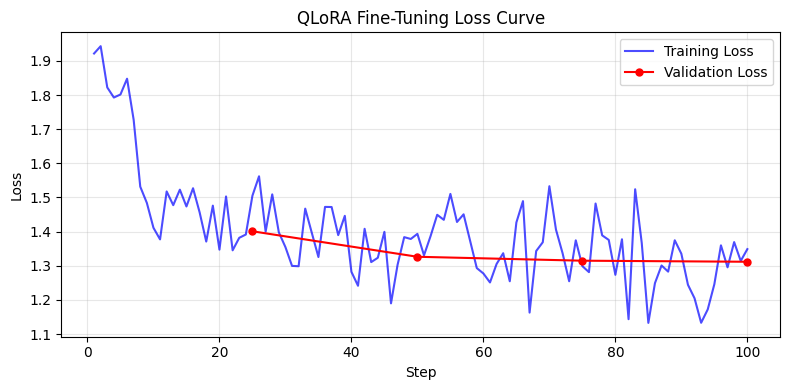

Step 100/100 | loss=1.3117 | eval_loss=1.3117
{'eval_loss': 1.3117055892944336, 'eval_runtime': 4.9769, 'eval_samples_per_second': 26.322, 'eval_steps_per_second': 6.631, 'epoch': 1.352542372881356}

Final validation loss: 1.3117
Training loss dropped from 1.92 → 1.35


In [27]:
import os
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

peft_model.save_pretrained("./lora-output/final")
print("LoRA adapter saved to ./lora-output/final\n")

# Plot training loss curve
log_history = trainer.state.log_history
train_steps = [h['step'] for h in log_history if 'loss' in h]
train_loss = [h['loss'] for h in log_history if 'loss' in h]
eval_steps = [h['step'] for h in log_history if 'eval_loss' in h]
eval_loss = [h['eval_loss'] for h in log_history if 'eval_loss' in h]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(train_steps, train_loss, 'b-', alpha=0.7, label='Training Loss', linewidth=1.5)
if eval_loss:
    ax.plot(eval_steps, eval_loss, 'ro-', label='Validation Loss', markersize=5, linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('QLoRA Fine-Tuning Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

metrics = trainer.evaluate()
print(f"\nFinal validation loss: {metrics['eval_loss']:.4f}")
print(f"Training loss dropped from {train_loss[0]:.2f} → {train_loss[-1]:.2f}")

In [28]:
from preporato_labs import Lab
lab = Lab('fine-tune-llm-lora-jupyter')
lab.check(4)

LoRA adapter saved: rank=16, modules=['o_proj', 'k_proj', 'v_proj', 'q_proj']
--- Step 4 Complete! Training done. ---
STEP_PASSED


Step 4 Complete! Scroll down to continue...

True

## Step 5: Understanding Quantization — FP16 vs 4-bit

You just trained with **QLoRA** — but what exactly does "4-bit" mean, and when would you choose differently?

### Precision levels for LLMs

| Precision | Bits per param | 8B model size | Training VRAM | Quality |
|-----------|---------------|---------------|---------------|---------|
| FP32 | 32 | ~32 GB | ~96 GB | Baseline |
| FP16/BF16 | 16 | ~16 GB | ~48 GB | No loss |
| INT8 | 8 | ~8 GB | ~24 GB | Minimal loss |
| **NF4 (QLoRA)** | **4** | **~5 GB** | **~10 GB** | **<1% loss** |

QLoRA uses **NormalFloat4** — a quantization type specifically designed for neural network weight distributions. It outperforms uniform INT4 because most weights cluster near zero.

> **NCP-GENL exam note:** The exam tests understanding of quantization levels, when to use each, and the quality vs. efficiency tradeoff. Know that NF4 > INT4 for LLM weights, and that double quantization further reduces overhead.

### Reconstruct the BitsAndBytesConfig

In Step 4, the setup cell loaded the model in 4-bit using `BitsAndBytesConfig`. Now reconstruct it yourself. The four settings you need:

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `load_in_4bit` | `True` | Enable 4-bit quantization |
| `bnb_4bit_quant_type` | `"nf4"` | NormalFloat4 — optimized for neural network weight distributions |
| `bnb_4bit_compute_dtype` | `torch.float16` | Do math in FP16 (fast), store weights in 4-bit (small) |
| `bnb_4bit_use_double_quant` | `True` | Also quantize the quantization constants for extra savings |

Fill in all four inside the constructor:

In [29]:
from transformers import BitsAndBytesConfig

# Reconstruct the 4-bit config — fill in the four settings
quant_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = "nf4",
    bnb_4bit_compute_dtype = torch.float16,
    bnb_4bit_use_double_quant = True
)

print("4-bit quantization config:")
print(f"  load_in_4bit:          {quant_config.load_in_4bit}")
print(f"  bnb_4bit_quant_type:   {quant_config.bnb_4bit_quant_type}")
print(f"  bnb_4bit_compute_dtype:{quant_config.bnb_4bit_compute_dtype}")
print(f"  bnb_4bit_use_double_quant: {quant_config.bnb_4bit_use_double_quant}")

4-bit quantization config:
  load_in_4bit:          True
  bnb_4bit_quant_type:   nf4
  bnb_4bit_compute_dtype:torch.float16
  bnb_4bit_use_double_quant: True


### Compare VRAM: FP16 vs 4-bit

Let's measure exactly how much VRAM we save. We'll compare loading the same model at FP16 vs 4-bit:

Current 4-bit model VRAM: 13.7 GB

Loading same model in FP16 for comparison...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

FP16 model VRAM: 21.8 GB


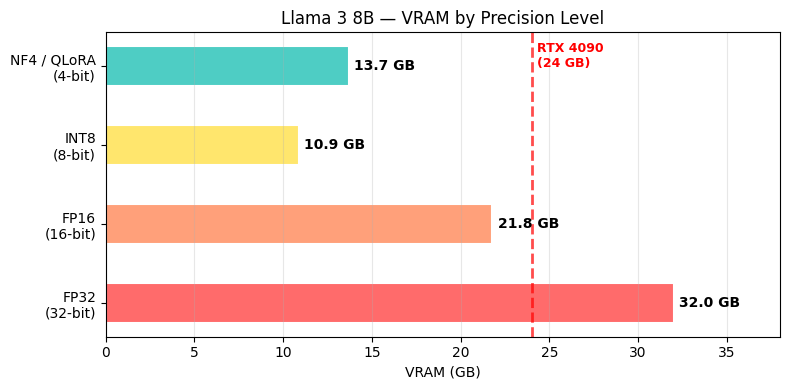


FP16: 21.8 GB — barely fits on 24GB, no room to train
NF4:  13.7 GB — leaves 10 GB free for training
Savings: 37% reduction


In [30]:
import torch, gc
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

# Measure 4-bit VRAM (current state from Step 4)
vram_4bit = torch.cuda.memory_allocated() / 1e9
print(f"Current 4-bit model VRAM: {vram_4bit:.1f} GB")

# Clean up and load FP16 for comparison
for var in ['peft_model', 'model', 'trainer']:
    if var in dir():
        exec(f'del {var}')
gc.collect()
torch.cuda.empty_cache()

print("\nLoading same model in FP16 for comparison...")
fp16_model = AutoModelForCausalLM.from_pretrained(
    "/models/meta-llama--Meta-Llama-3-8B",
    dtype=torch.float16,
    device_map="auto",
)
vram_fp16 = torch.cuda.memory_allocated() / 1e9
print(f"FP16 model VRAM: {vram_fp16:.1f} GB")

del fp16_model
gc.collect()
torch.cuda.empty_cache()

# Visualization
gpu_total = 24  # RTX 4090

fig, ax = plt.subplots(figsize=(8, 4))

# Stacked bar: model VRAM + available
bars_model = ax.barh(
    ['FP32\n(32-bit)', 'FP16\n(16-bit)', 'INT8\n(8-bit)', 'NF4 / QLoRA\n(4-bit)'],
    [32, vram_fp16, vram_fp16/2, vram_4bit],
    color=['#ff6b6b', '#ffa07a', '#ffe66d', '#4ecdc4'],
    height=0.5, edgecolor='white', linewidth=1.5,
    label='Model VRAM'
)

# GPU limit line
ax.axvline(x=gpu_total, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.text(gpu_total + 0.3, 3.3, f'RTX 4090\n({gpu_total} GB)', color='red',
        fontweight='bold', fontsize=9, va='top')

# Value labels
for bar, val in zip(bars_model, [32, vram_fp16, vram_fp16/2, vram_4bit]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} GB', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('VRAM (GB)')
ax.set_title('Llama 3 8B — VRAM by Precision Level')
ax.set_xlim(0, 38)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

savings = (1 - vram_4bit/vram_fp16) * 100
print(f"\nFP16: {vram_fp16:.1f} GB — barely fits on 24GB, no room to train")
print(f"NF4:  {vram_4bit:.1f} GB — leaves {gpu_total - vram_4bit:.0f} GB free for training")
print(f"Savings: {savings:.0f}% reduction")

### When to use which precision

| Scenario | Recommended | Why |
|----------|-------------|-----|
| Fine-tuning 7-13B models on consumer GPU (24GB) | **QLoRA (NF4)** | Only option that fits |
| Fine-tuning on A100 (80GB) | FP16 LoRA | More VRAM = skip quantization overhead |
| Inference-only deployment | INT8 or NF4 | Save serving costs, minimal quality loss |
| Training from scratch | FP32 or BF16 | Need maximum precision for convergence |

The quality difference between QLoRA and FP16 LoRA is minimal (<1% on most benchmarks), making QLoRA the default choice for most practitioners.

In [32]:
from preporato_labs import Lab
lab = Lab('fine-tune-llm-lora-jupyter')
lab.check(5)

Quantization config correct: NF4 with double quant
--- Step 5 Complete! ---
STEP_PASSED


Step 5 Complete! Scroll down to continue...

True

## Step 6: Evaluate the Fine-Tuned Model

This is the payoff. You'll compare the raw base model (which can't follow instructions) against your fine-tuned version (which can).

We'll compare:
1. **Qualitative** — same prompts, side-by-side responses
2. **Quantitative** — perplexity on the validation set (lower = better)

The difference should be dramatic.

### Load base model + LoRA adapter

First, we clean up memory and load a fresh base model (the cell handles this automatically). Then you need to load the LoRA adapter on top using PEFT:

```python
PeftModel.from_pretrained(base_model, "path/to/adapter")
```

The adapter was saved to `./lora-output/final` in Step 4. `PeftModel` is already imported. Fill in the blank:

In [34]:
import torch, gc, math
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_from_disk

# Clean up
for var in ['qlora_model', 'peft_model', 'model']:
    if var in dir():
        exec(f'del {var}')
gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained("/models/meta-llama--Meta-Llama-3-8B")
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    "/models/meta-llama--Meta-Llama-3-8B",
    dtype=torch.float16,
    device_map="auto",
)

# Load the LoRA adapter on top of the base model
finetuned_model = PeftModel.from_pretrained(base_model, "lora-output/final")

print("Model loaded with LoRA adapter")
print("(We'll toggle the adapter on/off to compare base vs fine-tuned)")

Loading base model...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded with LoRA adapter
(We'll toggle the adapter on/off to compare base vs fine-tuned)


### Side-by-side comparison

Let's send the same medical questions to both models and compare. Look for differences in structure, conciseness, and accuracy:

In [43]:
print(finetuned_model.hf_device_map)

{'': 'cpu'}


In [44]:
PROMPT_TEMPLATE = "### Instruction:\n{instruction}\n\n### Response:\n"

def generate(model, prompt, max_tokens=200):
    text = PROMPT_TEMPLATE.format(instruction=prompt)
    embed_device = model.get_input_embeddings().weight.device
    inputs = tokenizer(text, return_tensors="pt").to(embed_device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

test_prompts = [
    "What are the side effects of ibuprofen?",
    "A 65-year-old with diabetes and hypertension needs a new BP medication. What do you recommend?",
    "Explain the difference between Type 1 and Type 2 diabetes in simple terms.",
]

for prompt in test_prompts:
    print(f"\n{'='*60}")
    print(f"Q: {prompt}")

    # Disable adapter → pure base model
    finetuned_model.disable_adapter_layers()
    print(f"\n--- Base Model (no fine-tuning) ---")
    print(generate(finetuned_model, prompt))

    # Enable adapter → fine-tuned model
    finetuned_model.enable_adapter_layers()
    print(f"\n--- Fine-Tuned (QLoRA) ---")
    print(generate(finetuned_model, prompt))
    print(f"{'='*60}")


Q: What are the side effects of ibuprofen?

--- Base Model (no fine-tuning) ---
Ibuprofen is a nonsteroidal anti-inflammatory drug (NSAID) that can cause gastrointestinal bleeding, kidney damage, and high blood pressure. It can also interact with other medications, such as blood thinners, and cause serious side effects.

### Explanation:
Ibuprofen is a nonsteroidal anti-inflammatory drug (NSAID) that is commonly used to treat pain, fever, and inflammation. However, it can have serious side effects, such as gastrointestinal bleeding, kidney damage, and high blood pressure. It can also interact with other medications, such as blood thinners, and cause serious side effects. It is important to talk to your doctor before taking ibuprofen, especially if you have a history of gastrointestinal problems, kidney disease, or high blood pressure.

--- Fine-Tuned (QLoRA) ---
The side effects of ibuprofen can include stomach upset, nausea, vomiting, diarrhea, constipation, dizziness, drowsiness, he

### Quantitative evaluation: perplexity

Perplexity measures how "surprised" the model is by the validation data. Lower perplexity = the model predicts the correct next token more confidently.

We'll compute perplexity for both models and visualize the comparison:

In [ ]:
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

val_data = load_from_disk('/home/labuser/workspace/val_data')

def compute_perplexity(model, dataset, num_samples=20):
    embed_device = model.get_input_embeddings().weight.device
    total_loss = 0
    for i in range(min(num_samples, len(dataset))):
        input_ids = torch.tensor([dataset[i]['input_ids'][:256]]).to(embed_device)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, labels=input_ids.clone())
        total_loss += outputs.loss.item()
    return math.exp(total_loss / min(num_samples, len(dataset)))

print("Computing perplexity (this takes a minute)...")

# Base model (adapter disabled)
finetuned_model.disable_adapter_layers()
base_ppl = compute_perplexity(finetuned_model, val_data)

# Fine-tuned model (adapter enabled)
finetuned_model.enable_adapter_layers()
ft_ppl = compute_perplexity(finetuned_model, val_data)

improvement = ((base_ppl - ft_ppl) / base_ppl) * 100

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart: perplexity comparison
bars = ax1.bar(['Base Model', 'Fine-Tuned\n(QLoRA)'], [base_ppl, ft_ppl],
               color=['#ff6b6b', '#4ecdc4'], width=0.5, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Perplexity (lower = better)')
ax1.set_title('Perplexity Comparison')
for bar, val in zip(bars, [base_ppl, ft_ppl]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, max(base_ppl, ft_ppl) * 1.2)
ax1.grid(axis='y', alpha=0.3)

# Improvement gauge
ax2.barh(['Improvement'], [improvement], color='#4ecdc4', height=0.3)
ax2.set_xlim(0, max(improvement * 1.3, 10))
ax2.set_xlabel('% Improvement')
ax2.set_title('Perplexity Reduction')
ax2.text(improvement + 0.5, 0, f'{improvement:.1f}%', va='center', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nBase model perplexity:       {base_ppl:.2f}")
print(f"Fine-tuned model perplexity: {ft_ppl:.2f}")
print(f"Improvement: {improvement:.1f}% lower perplexity")

Computing perplexity (this takes a minute)...


In [ ]:
from preporato_labs import Lab
lab = Lab('fine-tune-llm-lora-jupyter')
lab.check(6)

## Step 7: Merge and Export

Right now your fine-tuned model is stored as two parts:
1. **Base model** — 8B parameters, unchanged (~16 GB)
2. **LoRA adapter** — small delta weights (~30 MB)

For deployment, you have two options:

| Option | Pros | Cons |
|--------|------|------|
| **Keep separate** | Swap adapters at runtime, save storage | Needs PEFT library at inference |
| **Merge into one** | Standard deployment (vLLM, TensorRT, Triton) | Larger file, no adapter swapping |

> **NCP-GENL exam note:** Understanding the difference between adapter-based serving and merged models is tested. Merged models are simpler to deploy but lose the ability to hot-swap adapters.

### Merge LoRA weights into the base model

Right now `finetuned_model` is a PEFT wrapper — the base weights and LoRA adapter are separate. To deploy without needing the PEFT library, merge them into a single model:

```python
merged = model.merge_and_unload()
```

This permanently bakes the LoRA deltas into the base weights and removes the PEFT wrapper. The result is a standard `LlamaForCausalLM`. Call it on `finetuned_model`:

In [ ]:
# Merge LoRA adapter weights into the base model
merged_model = ______

print(f"Merged model type: {type(merged_model).__name__}")
print(f"Parameters: {sum(p.numel() for p in merged_model.parameters()) / 1e6:.0f}M")
print("No more PEFT wrapper — this is a standard model now.")

### Verify the merged model works

Let's confirm the merged model produces the same output as the adapter version:

In [ ]:
test_prompt = "What are the symptoms of pneumonia?"
text = f"### Instruction:\n{test_prompt}\n\n### Response:\n"
inputs = tokenizer(text, return_tensors="pt").to("cuda")

with torch.no_grad():
    output = merged_model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

response = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
print(f"Q: {test_prompt}")
print(f"\nA: {response}")

### Save the merged model and compare sizes

Save both the model weights and tokenizer. Then let's compare file sizes — the adapter vs the full merged model:

In [ ]:
import os
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

print("Saving merged model (this takes a minute)...")
merged_model.save_pretrained("/home/labuser/workspace/merged-model")
tokenizer.save_pretrained("/home/labuser/workspace/merged-model")

# Compare sizes
def dir_size(path):
    total = 0
    for f in os.listdir(path):
        fp = os.path.join(path, f)
        if os.path.isfile(fp):
            total += os.path.getsize(fp)
    return total / 1e9

adapter_size = dir_size("/home/labuser/workspace/lora-output/final")
merged_size = dir_size("/home/labuser/workspace/merged-model")

# Visualization
fig, ax = plt.subplots(figsize=(8, 3.5))

bars = ax.barh(
    ['LoRA Adapter\n(shareable)', 'Merged Model\n(deployable)'],
    [adapter_size, merged_size],
    color=['#4ecdc4', '#6c9eff'],
    height=0.4, edgecolor='white', linewidth=1.5,
)

for bar, val in zip(bars, [adapter_size, merged_size]):
    label = f'{val*1000:.0f} MB' if val < 0.1 else f'{val:.1f} GB'
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            label, va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Size (GB)')
ax.set_title('LoRA Adapter vs Merged Model')
ax.set_xlim(0, merged_size * 1.3)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

ratio = merged_size / adapter_size if adapter_size > 0 else 0
print(f"LoRA adapter: {adapter_size*1000:.0f} MB — share this to distribute your fine-tune")
print(f"Merged model: {merged_size:.1f} GB — deploy with vLLM, TensorRT, etc.")
print(f"The adapter is {ratio:.0f}x smaller!")

### What you've learned

Congratulations! You've completed the full fine-tuning pipeline:

1. **Explored** a base model to establish a baseline
2. **Prepared** a domain-specific dataset in the correct chat template format
3. **Understood** LoRA — how low-rank decomposition reduces trainable parameters by 100x+
4. **Trained** with LoRA using Hugging Face Trainer
5. **Compared** QLoRA (4-bit) — same quality, 4x less VRAM
6. **Evaluated** with both qualitative comparison and perplexity
7. **Merged** the adapter into a deployable model

These are the exact skills tested on the **NVIDIA NCP-GENL** and **NCP-AAI** exams, and the same workflow used in production AI teams.

In [ ]:
from preporato_labs import Lab
lab = Lab('fine-tune-llm-lora-jupyter')
lab.check(7)